# 🧠 Rock-Paper-Scissors — CNN from Scratch

---

## 🎯 Objective

Build a **Convolutional Neural Network (CNN)** entirely from scratch using Keras to classify
images of hand gestures into three classes: **Rock**, **Paper**, and **Scissors**.

### What You Will Learn

| Topic | Description |
|-------|-------------|
| Data loading | Load pre-split image datasets with `image_dataset_from_directory` |
| Pipeline optimization | Use `.cache()`, `.shuffle()`, `.prefetch()` for fast training |
| Data augmentation | Apply spatial & colour transforms to reduce overfitting |
| CNN architecture | Design Conv → Pool → Dense blocks from scratch |
| Callbacks | EarlyStopping, ReduceLROnPlateau, ModelCheckpoint |
| Evaluation | Accuracy, loss curves, test-set performance |

### Prerequisites

- Run **`data_split.ipynb`** first to generate `split_data/train`, `split_data/val`, `split_data/test`.

---

## Step 1 — Import Libraries

In [17]:
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import layers
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


---

## Step 2 — Configuration

All hyper-parameters and paths in one place for easy experimentation.

In [18]:
# ╔══════════════════════════════════════════════╗
# ║        CONFIGURATION — CHANGE HERE           ║
# ╚══════════════════════════════════════════════╝

IMAGE_SIZE   = (150, 150)
BATCH_SIZE   = 32
EPOCHS       = 50
SEED         = 42

# Paths (relative to this notebook)
TRAIN_DIR    = '../split_data/train'
VAL_DIR      = '../split_data/val'
TEST_DIR     = '../split_data/test'
WEIGHTS_DIR  = '../weights/scratch'

os.makedirs(WEIGHTS_DIR, exist_ok=True)

---

## Step 3 — Load the Data

We use `image_dataset_from_directory` to load images directly from the pre-split folders.

> 📌 **No `validation_split` here** — we already split the data in `data_split.ipynb`.
> This gives us full control and ensures consistency across all models.

In [19]:
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
)

val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

print(f"\n📦 Classes: {CLASS_NAMES}")
print(f"📦 Number of classes: {NUM_CLASSES}")

Found 2022 files belonging to 3 classes.
Found 432 files belonging to 3 classes.
Found 438 files belonging to 3 classes.

📦 Classes: ['paper', 'rock', 'scissors']
📦 Number of classes: 3


---

## Step 4 — Visualize Raw Samples

Always look at your data before training. This helper function displays a 3×3 grid of samples.

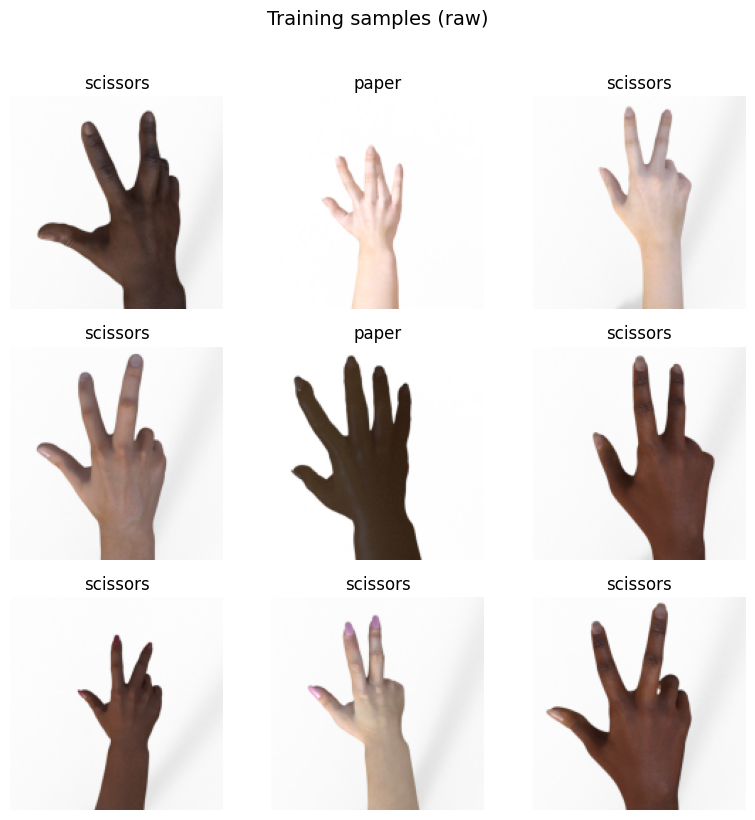

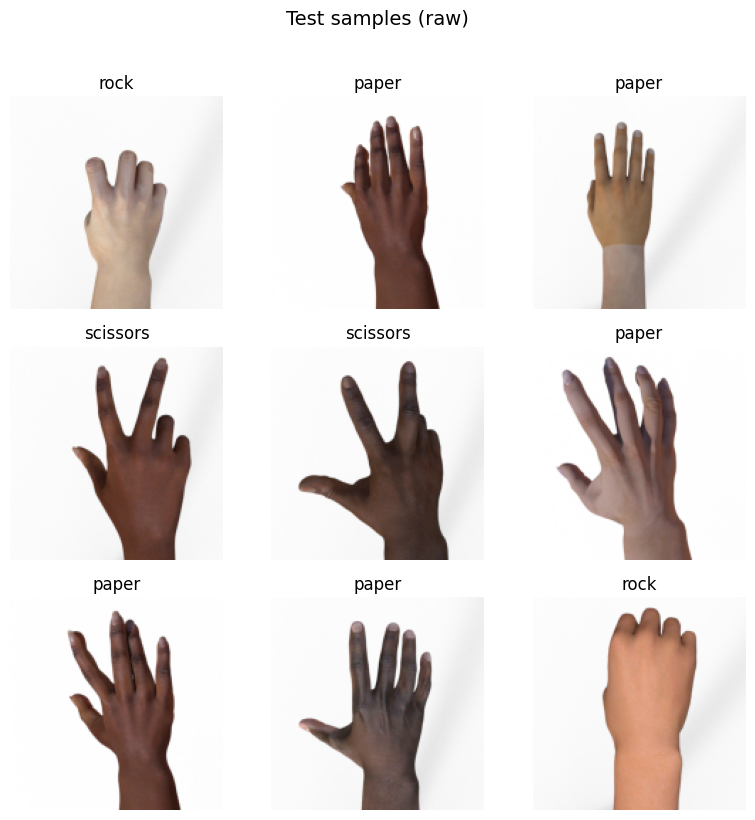

In [20]:
def show_batch(dataset, class_names, title, n=9):
    plt.figure(figsize=(8, 8))
    for images, labels in dataset.take(1):
        for i in range(min(n, images.shape[0])):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype('uint8'))
            plt.title(class_names[int(labels[i])])
            plt.axis('off')
    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

show_batch(train_ds, CLASS_NAMES, 'Training samples (raw)')
show_batch(test_ds,  CLASS_NAMES, 'Test samples (raw)')

---

## Step 5 — Optimize the Input Pipeline

| Method | Purpose |
|--------|---------|
| `.cache()` | Keep images in memory after first load — avoids reading from disk every epoch |
| `.shuffle()` | Randomize order each epoch to prevent the model from learning data order |
| `.prefetch()` | Pre-load the next batch while the GPU processes the current one |

In [21]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

---

## Step 6 — Data Augmentation

Data augmentation **artificially expands** the training set by applying random transformations
to each image every epoch. This helps the model generalize and reduces overfitting.

### Augmentations Used

| Category | Layer | Effect |
|----------|-------|--------|
| **Spatial** | `RandomFlip` | Horizontal mirror |
| | `RandomRotation` | Rotate ±20% of a full turn |
| | `RandomZoom` | Zoom in/out by 20% |
| | `RandomTranslation` | Shift 10% horizontally & vertically |
| **Colour** | `RandomContrast` | Vary contrast by 20% |
| | `RandomBrightness` | Vary brightness by 20% |
| **Noise** | `GaussianNoise` | Add slight random noise |

In [22]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomShear(0.2),
    layers.RandomTranslation(0.1, 0.1),

    # ── Colour / Appearance ──
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),

    # ── Noise / Regularization ──
    layers.GaussianNoise(0.05),
], name='data_augmentation')

### Preview Augmentations

Let's see what the augmentations look like on a **single image**.
Each cell shows the same image with a different random transformation applied.

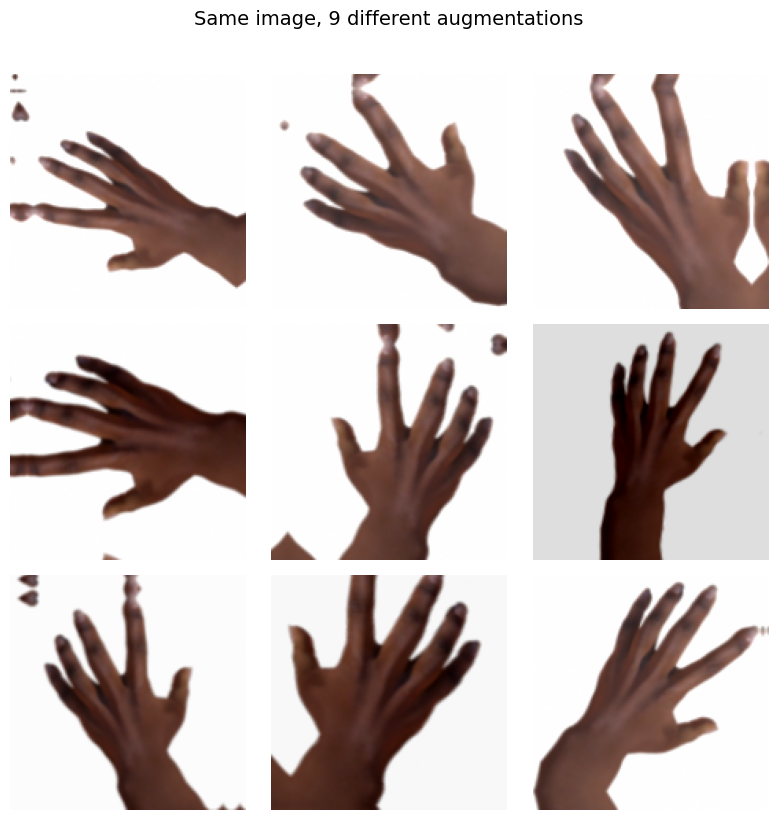

In [23]:
plt.figure(figsize=(8, 8))
for images, _ in train_ds.take(1):
    first = images[0]
    for i in range(9):
        augmented = data_augmentation(tf.expand_dims(first, 0), training=True)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(augmented[0], tf.uint8))
        plt.axis('off')
plt.suptitle('Same image, 9 different augmentations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## Step 7 — Build the CNN Model

Our architecture follows a classic pattern:

```
Input → Augmentation → Rescaling → [Conv → Pool] × 3 → Flatten → Dense → Output
```

| Block | Filters | Kernel | Purpose |
|-------|---------|--------|---------|
| Block 1 | 16 | 3×3 | Detect edges, simple patterns |
| Block 2 | 32 | 3×3 | Detect shapes, textures |
| Block 3 | 64 | 3×3 | Detect high-level features |
| Dense | 128 | — | Combine features for classification |

In [24]:
model = keras.Sequential([
    layers.Input(shape=IMAGE_SIZE + (3,)),

    # Augmentation (only active during training)
    data_augmentation,

    # Normalize pixel values to [0, 1]
    layers.Rescaling(1.0 / 255),

    # Block 1
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax'),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,307 (10.22 MB)

 Trainable params: 2,678,307 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

---

## Step 8 — Compile the Model

| Setting | Value | Why |
|---------|-------|-----|
| Optimizer | Adam | Adaptive learning rate — works well out of the box |
| Loss | Sparse Categorical Crossentropy | Integer labels, multi-class |
| Metric | Accuracy | Easy to interpret |

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

---

## Step 9 — Define Callbacks

Callbacks automate common training decisions:

| Callback | Purpose |
|----------|---------|
| **EarlyStopping** | Stop training if `val_loss` doesn't improve for 3 epochs; restore the best weights |
| **ReduceLROnPlateau** | Halve the learning rate if `val_loss` plateaus for 2 epochs |
| **ModelCheckpoint** | Save the best model (lowest `val_loss`) to `weights/scratch/` |

In [26]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(WEIGHTS_DIR, 'best.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=0,
    ),
]

---

## Step 10 — Train the Model

In [27]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

print(f"\n✅ Training complete. Best model saved to: {WEIGHTS_DIR}/best.keras")

Epoch 1/50


64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - accuracy: 0.4530 - loss: 1.0666 - val_accuracy: 0.5625 - val_loss: 0.7977 - learning_rate: 0.0010
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.6810 - loss: 0.7077 - val_accuracy: 0.8148 - val_loss: 0.4100 - learning_rate: 0.0010
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.7883 - loss: 0.5269 - val_accuracy: 0.8866 - val_loss: 0.3131 - learning_rate: 0.0010
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.8452 - loss: 0.4117 - val_accuracy: 0.9583 - val_loss: 0.1759 - learning_rate: 0.0010
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.8630 - loss: 0.3660 - val_accuracy: 0.9282 - val_loss: 0.1915 - learning_rate: 0.0010
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.8793 - loss: 0.3345 - val_accuracy: 0.9421 - val_loss: 0.1396 - learning_rate: 0.0010
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9031 - loss: 0.2836 - val_accura

---

## Step 11 — Evaluate on the Test Set

The test set was **never seen** during training — this gives an honest measure of performance.

In [28]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"\n📊 Test Accuracy: {test_acc:.4f}")
print(f"📊 Test Loss:     {test_loss:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0061

📊 Test Accuracy: 1.0000
📊 Test Loss:     0.0061


---

## Step 12 — Training Curves

Plotting accuracy and loss over epochs helps diagnose:
- **Overfitting** — training improves but validation degrades
- **Underfitting** — both are poor
- **Good fit** — both improve together and converge

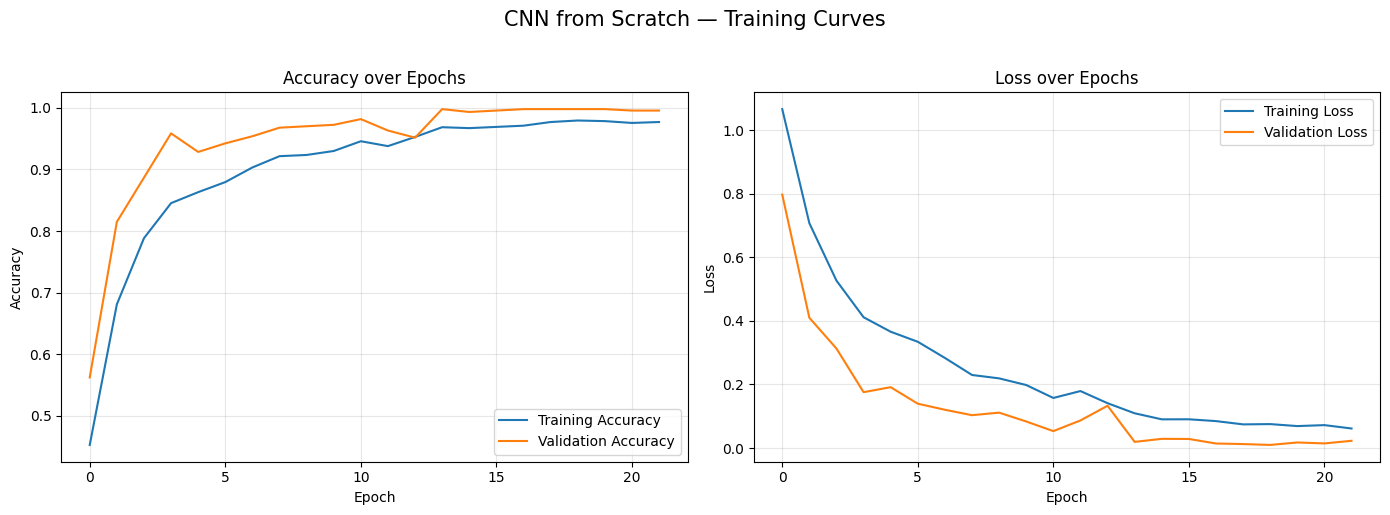

In [29]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(acc, label='Training Accuracy')
axes[0].plot(val_acc, label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(loss, label='Training Loss')
axes[1].plot(val_loss, label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN from Scratch — Training Curves', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---

## 📚 Summary

| Metric | Value |
|--------|-------|
| Architecture | Custom 3-block CNN |
| Augmentation | Flip, Rotation, Zoom, Translation, Contrast, Brightness, Noise |
| Callbacks | EarlyStopping, ReduceLROnPlateau, ModelCheckpoint |
| Model saved to | `weights/scratch/best.keras` |

### Key Takeaways for Students

1. **Always visualize your data** before training — catch problems early.
2. **Data augmentation** is essential when the dataset is small.
3. **Callbacks save you time** — no need to manually monitor training.
4. **Test accuracy is the only honest metric** — never tune hyper-parameters on it.